Financial Inclusion in Africa 

Business Context and Goal

Financial inclusion remains one of the main obstacles to economic and human development in Africa. For example, across Kenya, Rwanda, Tanzania, and Uganda only 9.1 million adults (or 14% of adults) have access to or use a commercial bank account.

Traditionally, access to bank accounts has been regarded as an indicator of financial inclusion. Despite the proliferation of mobile money in Africa, and the growth of innovative fintech solutions, banks still play a pivotal role in facilitating access to financial services. Access to bank accounts enable households to save and make payments while also helping businesses build up their credit-worthiness and improve their access to loans, insurance, and related services. Therefore, access to bank accounts is an essential contributor to long-term economic growth.

The objective of this competition is to create a machine learning model to predict which individuals are most likely to have or use a bank account. The models and solutions developed can provide an indication of the state of financial inclusion in Kenya, Rwanda, Tanzania and Uganda, while providing insights into some of the key factors driving individuals’ financial security.

Zindi scores us on MAE, but on a 14/86 split accuracy is misleading, so for the business we track recall and precision on account-holders

Main Project Requirements

Predict the likelihood of the person having a bank account or not (Yes = 1, No = 0), for each unique id in the test dataset 

Train a model on 70% of the data 

Test your model on the final 30% of the data

The data is formed across four East African countries - Kenya, Rwanda, Tanzania, and Uganda.

The main dataset contains demographic information and what financial services are used by approximately 33,600 individuals across East Africa. 

This data was extracted from various Finscope surveys ranging from 2016 to 2018

Steps to take - Tasks to be done

obtain the data
load the data
review the data
clean the data
train/test split the data
explore the training data
carry out feature engineering
create a baseline model
predict an average training score
train the model
evaluate the model
iteration of modelling to find the best model
decide on the final model
produce deliverables and presentation for c-suite presentation

In [79]:
# import the necessary libraries for data management

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# obtain and load the data

train = pd.read_csv('financial-inclusion-in-africa/train.csv')
test = pd.read_csv('financial-inclusion-in-africa/test.csv')
variables = pd.read_csv('financial-inclusion-in-africa/VariableDefinitions.csv')
sample = pd.read_csv('financial-inclusion-in-africa/SampleSubmission.csv')



In [80]:
# preview the data

print(train.head())
print(test.head())
print(sample.head())
print(variables.head(12))

  country  year    uniqueid bank_account location_type cellphone_access  \
0   Kenya  2018  uniqueid_1          Yes         Rural              Yes   
1   Kenya  2018  uniqueid_2           No         Rural               No   
2   Kenya  2018  uniqueid_3          Yes         Urban              Yes   
3   Kenya  2018  uniqueid_4           No         Rural              Yes   
4   Kenya  2018  uniqueid_5           No         Urban               No   

   household_size  age_of_respondent gender_of_respondent  \
0               3                 24               Female   
1               5                 70               Female   
2               5                 26                 Male   
3               5                 34               Female   
4               8                 26                 Male   

  relationship_with_head           marital_status  \
0                 Spouse  Married/Living together   
1      Head of Household                  Widowed   
2         Other relativ

In [81]:
# check the data

train.info()
test.info()
sample.info()
variables.info()

<class 'pandas.DataFrame'>
RangeIndex: 23524 entries, 0 to 23523
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   country                 23524 non-null  str  
 1   year                    23524 non-null  int64
 2   uniqueid                23524 non-null  str  
 3   bank_account            23524 non-null  str  
 4   location_type           23524 non-null  str  
 5   cellphone_access        23524 non-null  str  
 6   household_size          23524 non-null  int64
 7   age_of_respondent       23524 non-null  int64
 8   gender_of_respondent    23524 non-null  str  
 9   relationship_with_head  23524 non-null  str  
 10  marital_status          23524 non-null  str  
 11  education_level         23524 non-null  str  
 12  job_type                23524 non-null  str  
dtypes: int64(3), str(10)
memory usage: 2.3 MB
<class 'pandas.DataFrame'>
RangeIndex: 10086 entries, 0 to 10085
Data columns (total 12 co

(array([0, 1]), [Text(0, 0, 'No'), Text(1, 0, 'Yes')])

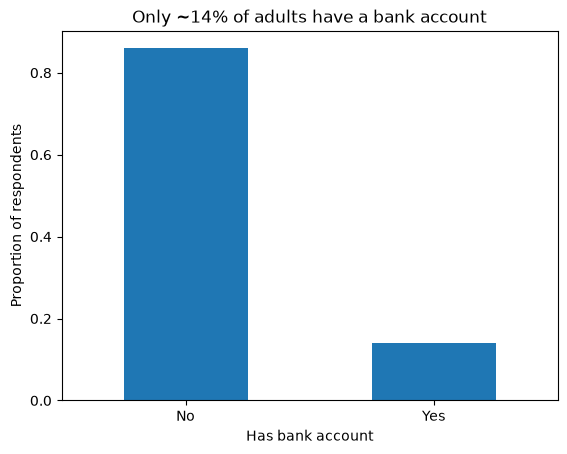

In [82]:
# Inspect the target

target = 'bank_account'

train[target].value_counts(normalize=True)

train[target].value_counts(normalize=True).plot(kind='bar')
ax = train[target].value_counts(normalize=True).plot(kind='bar')
ax.set_title('Only ~14% of adults have a bank account')
ax.set_xlabel('Has bank account')
ax.set_ylabel('Proportion of respondents')
plt.xticks(rotation=0)


In [83]:
# cleaning the data 1

# categoricals

cat_cols = ['country', 'year', 'location_type', 'cellphone_access', 'gender_of_respondent',
            'relationship_with_head', 'marital_status', 'education_level', 'job_type']

for col in cat_cols:
    print(col)
    print(train[col].value_counts())
    print()

# no typos discovered in categoricals

# some 'dont knows' and 'unknowns' which could be considered NaN's - the percentage against the total is very low so no adjustment since very low impact

# data is clean

country
country
Rwanda      8735
Tanzania    6620
Kenya       6068
Uganda      2101
Name: count, dtype: int64

year
year
2016    8735
2018    8169
2017    6620
Name: count, dtype: int64

location_type
location_type
Rural    14343
Urban     9181
Name: count, dtype: int64

cellphone_access
cellphone_access
Yes    17454
No      6070
Name: count, dtype: int64

gender_of_respondent
gender_of_respondent
Female    13877
Male       9647
Name: count, dtype: int64

relationship_with_head
relationship_with_head
Head of Household      12831
Spouse                  6520
Child                   2229
Parent                  1086
Other relative           668
Other non-relatives      190
Name: count, dtype: int64

marital_status
marital_status
Married/Living together    10749
Single/Never Married        7983
Widowed                     2708
Divorced/Seperated          2076
Dont know                      8
Name: count, dtype: int64

education_level
education_level
Primary education                  1279

In [84]:
# cleaning the data 2

# numerics

print(train[['age_of_respondent', 'household_size']].describe())


# minimum age is 16, maximum age is 100 (maybe rounded)

print(train['household_size'].value_counts().sort_index())

# minimum household size is 1 which seems plausible, max household size is 21 
# 21 for household size - seems high initially but it's clear from the sort index that there's a gradual increase which could be plausible based on location and different relationship styles
# no 0 household sizes - nothing to adjust

# nothing to clean

# Interesting to note: 
# Majority of respondents are female 
# Majority location is rural - 
# Uganda count of responses are significantly lower - only 9% of respondents

       age_of_respondent  household_size
count       23524.000000    23524.000000
mean           38.805220        3.797483
std            16.520569        2.227613
min            16.000000        1.000000
25%            26.000000        2.000000
50%            35.000000        3.000000
75%            49.000000        5.000000
max           100.000000       21.000000
household_size
1     3057
2     5229
3     3920
4     3474
5     2853
6     2096
7     1400
8      751
9      363
10     190
11      69
12      68
13      25
14      10
15      11
16       4
17       1
18       1
20       1
21       1
Name: count, dtype: int64


<Axes: xlabel='household_size'>

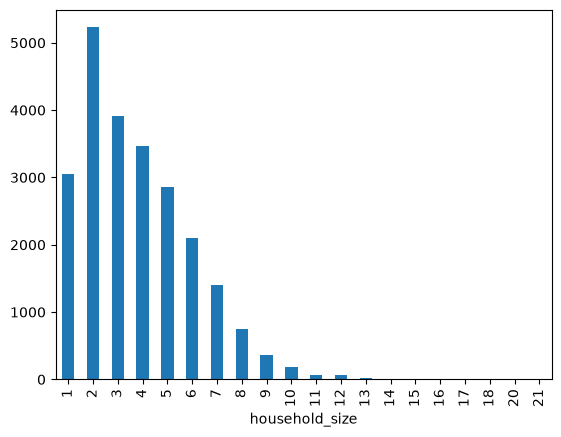

In [85]:
# visual representation of household size to better see the gradual increase up to 21

train['household_size'].value_counts().sort_index().plot(kind='bar')



<Axes: xlabel='age_of_respondent', ylabel='Count'>

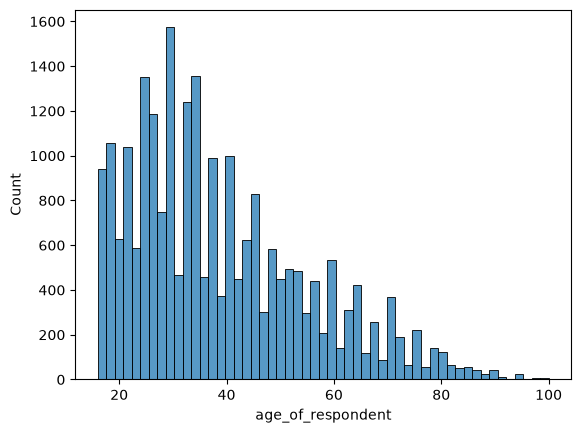

In [86]:
# visual representation of age of respondents to better see the gradual increase up to 100

sns.histplot(train['age_of_respondent'])

In [87]:
# train test split

from sklearn.model_selection import train_test_split

y = train[target]
X = train.drop(columns=[target, 'uniqueid'])

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20,
    random_state=42,
    stratify=y
)

print(y_train.value_counts(normalize=True))

print(y_val.value_counts(normalize=True))

# why stratify was included - this keeps the 14/86 ratio identical in both splits. 
# A plain random split can drift the rare positive class by a couple of percent from shuffle luck alone; 
# since our positive-class recall is measured against the validation set, an off-ratio validation set would make that number misleading. 
# Stratifying keeps the yardstick honest.

# the project request from Zindi describes a 70/30 split for train and test. However, our location validation ratio is 80/20

bank_account
No     0.859185
Yes    0.140815
Name: proportion, dtype: float64
bank_account
No     0.859299
Yes    0.140701
Name: proportion, dtype: float64


In [88]:
# convert bank_account 'yes/no' to 1 and 0 as required
# using a dictionary to map Yes to 1 and No to 0 as requested
# I carried this out **after** the previous steps intentional, as we move to baseline model and other modelling

y_train = y_train.map({'Yes': 1, 'No': 0})
y_val   = y_val.map({'Yes': 1, 'No': 0})

In [89]:
# baseline model 

from sklearn.metrics import accuracy_score, mean_absolute_error, recall_score
from sklearn.dummy import DummyClassifier
import numpy as np

majority_class = y_train.mode()[0]
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
baseline_preds = dummy.predict(X_val)

mae = mean_absolute_error(y_val, baseline_preds)
acc = accuracy_score(y_val, baseline_preds)
rec = recall_score(y_val, baseline_preds)         # positive class = 1 by default

print(f"Baseline predicts the majority class will be: {majority_class}")
print(f"MAE:      {mae:.3f}")   # ~0.141
print(f"Accuracy: {acc:.3f}")   # ~0.859
print(f"Recall:   {rec:.3f}")   # 0.000


Baseline predicts the majority class will be: 0
MAE:      0.141
Accuracy: 0.859
Recall:   0.000


In [90]:
# # Cross Validation and Preprocessing - this takes place after the DummyClassifier / Baseline prediction model

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

print(cat_cols)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['household_size', 'age_of_respondent']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)


from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate

# pipeline
pipe = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=1000)),
])

# cross validation
scores = cross_validate(
    pipe, X_train, y_train,
    cv=5,
    scoring=['neg_mean_absolute_error', 'recall', 'accuracy'],
)

print("MAE:     ", -scores['test_neg_mean_absolute_error'].mean())
print("Recall:  ", scores['test_recall'].mean())
print("Accuracy:", scores['test_accuracy'].mean())

['country', 'year', 'location_type', 'cellphone_access', 'gender_of_respondent', 'relationship_with_head', 'marital_status', 'education_level', 'job_type']
MAE:      0.11605301409241445
Recall:   0.3366037735849056
Accuracy: 0.8839469859075855


In [91]:
# Cross Validation
# evaluating the dummy model using the 5-fold cross validation as logistic regression

# this ensures a fair comparison
# look at the training data, find the majority class and always predict this class

from sklearn.dummy import DummyClassifier

dummy_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', DummyClassifier(strategy='most_frequent'))
])

dummy_scores = cross_validate(
    dummy_pipe,
    X_train,
    y_train,
    cv=5,
    scoring=['neg_mean_absolute_error', 'recall', 'accuracy']
)

print("Dummy MAE:     ", -dummy_scores['test_neg_mean_absolute_error'].mean())
print("Dummy Recall:  ", dummy_scores['test_recall'].mean())
print("Dummy Accuracy:", dummy_scores['test_accuracy'].mean())

Dummy MAE:      0.14081513523222225
Dummy Recall:   0.0
Dummy Accuracy: 0.8591848647677777


In [92]:
# Table comparing the cross validation results (logistic regression against dummy)

import pandas as pd

cv_results = pd.DataFrame({
    'Model': ['Dummy', 'Logistic Regression'],
    
    'MAE': [
        -dummy_scores['test_neg_mean_absolute_error'].mean(),
        -scores['test_neg_mean_absolute_error'].mean()
    ],
    
    'Accuracy': [
        dummy_scores['test_accuracy'].mean(),
        scores['test_accuracy'].mean()
    ],
    
    'Recall': [
        dummy_scores['test_recall'].mean(),
        scores['test_recall'].mean()
    ]
})

cv_results

# accuracy improved with the logistic regression


,Model,MAE,Accuracy,Recall
0,Dummy,0.140815,0.859185,0.000000
1,Logistic Regression,0.116053,0.883947,0.336604


In [93]:
# recall also gave us a wildly different outcome with 0.33

# However, this 0.33 is a mean which could be born of 5x similar numbers or 5x very different numbers to form the mean

# this could be the difference between stability and instability
# therefore its important to explore these 5x cross validation results and their stand deviation

print("Logistic Regression recall by fold:")
print(scores['test_recall'])

print("\nMean recall:")
print(scores['test_recall'].mean())

print("\nRecall standard deviation:")
print(scores['test_recall'].std())

mae_folds = -scores['test_neg_mean_absolute_error']

print("Logistic Regression MAE by fold:")
print(mae_folds)

print("\nMean MAE:")
print(mae_folds.mean())

print("\nMAE standard deviation:")
print(mae_folds.std())

Logistic Regression recall by fold:
[0.34716981 0.32830189 0.34528302 0.31509434 0.34716981]

Mean recall:
0.3366037735849056

Recall standard deviation:
0.012885563078463298
Logistic Regression MAE by fold:
[0.11742827 0.11689692 0.1118491  0.11636557 0.11772522]

Mean MAE:
0.11605301409241445

MAE standard deviation:
0.002152690344303277


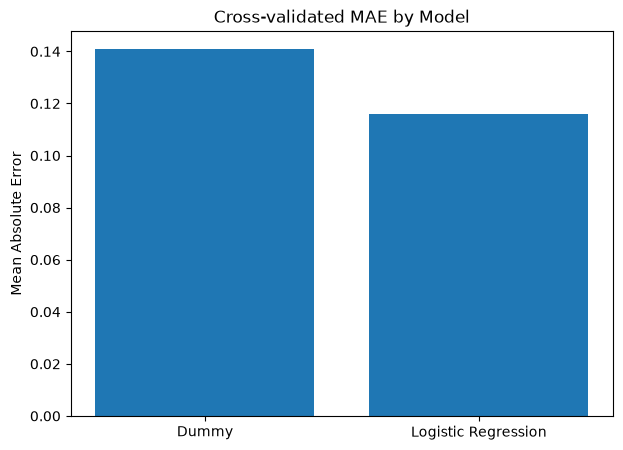

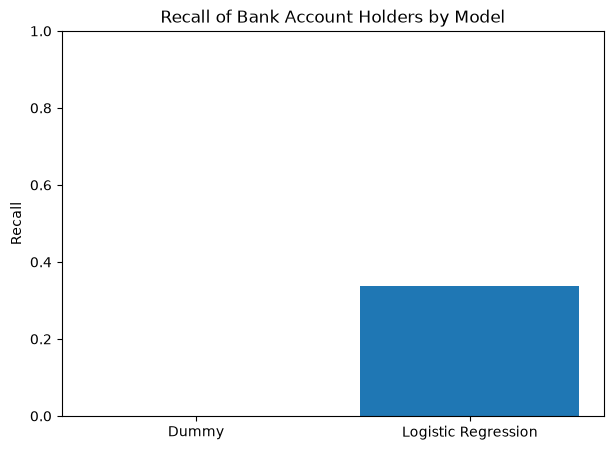

In [94]:
# Competition performance MAE

import matplotlib.pyplot as plt

models = ['Dummy', 'Logistic Regression']
mae = [
    -dummy_scores['test_neg_mean_absolute_error'].mean(),
    -scores['test_neg_mean_absolute_error'].mean()
]

plt.figure(figsize=(7, 5))
plt.bar(models, mae)

plt.ylabel('Mean Absolute Error')
plt.title('Cross-validated MAE by Model')

plt.show()

# positive-class performance Recall

recall = [
    dummy_scores['test_recall'].mean(),
    scores['test_recall'].mean()
]

plt.figure(figsize=(7, 5))
plt.bar(models, recall)

plt.ylabel('Recall')
plt.title('Recall of Bank Account Holders by Model')

plt.ylim(0, 1)

plt.show()

The first chart displays a lower mean absolute error - lower is better and logistic regression gives us this

The second chart demonstrates why the 86% Dummy accuracy is misleading. The logistic regression shows otherwise (34%)

In [95]:
# Model Comparisons

# Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

# evaluation
rf_scores = cross_validate(
    rf_pipe,
    X_train,
    y_train,
    cv=5,
    scoring=[
        'neg_mean_absolute_error',
        'recall',
        'accuracy'
    ]
)

print(
    "Random Forest MAE:",
    -rf_scores['test_neg_mean_absolute_error'].mean()
)

print(
    "Random Forest Recall:",
    rf_scores['test_recall'].mean()
)

print(
    "Random Forest Accuracy:",
    rf_scores['test_accuracy'].mean()
)

# check stability

rf_mae_folds = -rf_scores['test_neg_mean_absolute_error']

print("\nRecall by fold:")
print(rf_scores['test_recall'])

print("Recall SD:")
print(rf_scores['test_recall'].std())

print("\nMAE by fold:")
print(rf_mae_folds)

print("MAE SD:")
print(rf_mae_folds.std())

Random Forest MAE: 0.13592671865411385
Random Forest Recall: 0.37886792452830187
Random Forest Accuracy: 0.8640732813458862

Recall by fold:
[0.39811321 0.37924528 0.41320755 0.35471698 0.3490566 ]
Recall SD:
0.02458339241494693

MAE by fold:
[0.13363443 0.13390011 0.12885228 0.1424017  0.14084507]
MAE SD:
0.005010487488040432


Recall is higher which is better but remembering that a lower MAE is also better, Random Forest loses here. 

If we explore the stability too, Random forest is less stable with a high variation between folds for Recall and MAE (even if not considered unstable). Logistic Regression is more consistent at this stage.

We n

In [ ]:
# Boosted trees - XGBoost

# compares - finds mistakes in the previous - focuses on those mistakes - what errors remain
# works sequentially

from xgboost import XGBClassifier

xgb_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        eval_metric='logloss'
    ))
])

# evaluation
xgb_scores = cross_validate(
    xgb_pipe,
    X_train,
    y_train,
    cv=5,
    scoring=[
        'neg_mean_absolute_error',
        'recall',
        'accuracy'
    ]
)

# display
xgb_mae_folds = -xgb_scores['test_neg_mean_absolute_error']

print(
    "XGBoost MAE:",
    xgb_mae_folds.mean()
)

print(
    "XGBoost Recall:",
    xgb_scores['test_recall'].mean()
)

print(
    "XGBoost Accuracy:",
    xgb_scores['test_accuracy'].mean()
)

print("\nRecall by fold:")
print(xgb_scores['test_recall'])

print("Recall SD:")
print(xgb_scores['test_recall'].std())

print("\nMAE by fold:")
print(xgb_mae_folds)

print("MAE SD:")
print(xgb_mae_folds.std())

After reviewing these comparisons, its clear that XGBoost currently has the strongest overall predictive performance according to the primary MAE metric, while Random Forest achieves higher positive-class recall and Logistic Regression remains a strong, stable and interpretable benchmark

In [ ]:
# model comparison table

model_results = pd.DataFrame({
    'Model': [
        'Dummy',
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],
    
    'MAE': [
        -dummy_scores['test_neg_mean_absolute_error'].mean(),
        -scores['test_neg_mean_absolute_error'].mean(),
        -rf_scores['test_neg_mean_absolute_error'].mean(),
        -xgb_scores['test_neg_mean_absolute_error'].mean()
    ],
    
    'Accuracy': [
        dummy_scores['test_accuracy'].mean(),
        scores['test_accuracy'].mean(),
        rf_scores['test_accuracy'].mean(),
        xgb_scores['test_accuracy'].mean()
    ],
    
    'Recall': [
        dummy_scores['test_recall'].mean(),
        scores['test_recall'].mean(),
        rf_scores['test_recall'].mean(),
        xgb_scores['test_recall'].mean()
    ]
})

model_results

,Model,MAE,Accuracy,Recall
0,Dummy,0.140815,0.859185,0.000000
1,Logistic Regression,0.116053,0.883947,0.336604
2,Random Forest,0.135927,0.864073,0.378868
3,XGBoost,0.112865,0.887135,0.330189


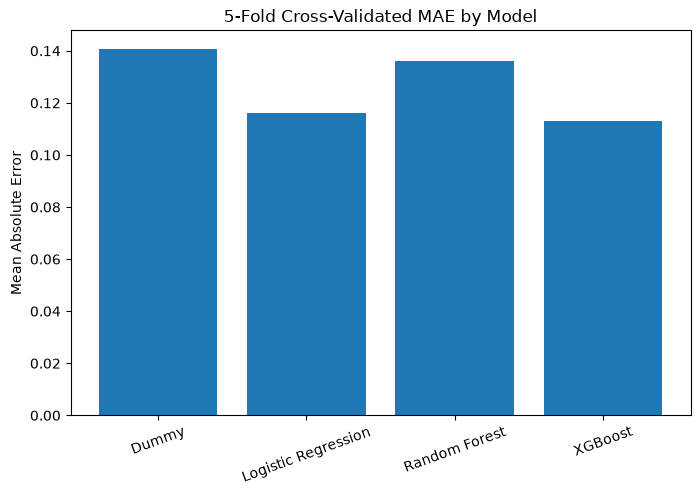

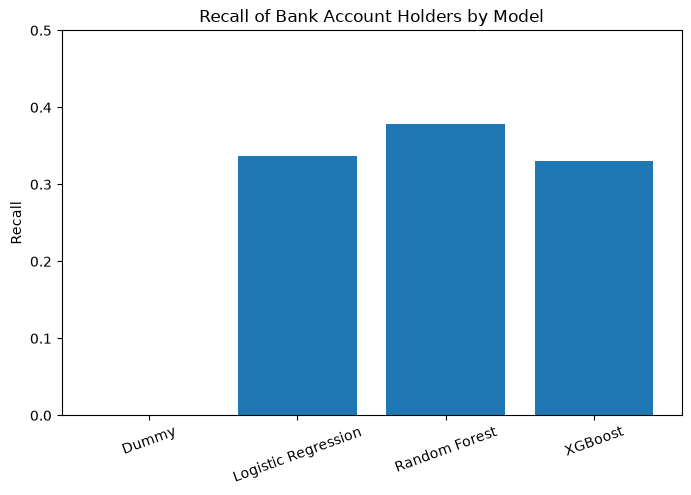

In [98]:
# MAE Chart

plt.figure(figsize=(8, 5))

plt.bar(
    model_results['Model'],
    model_results['MAE']
)

plt.ylabel('Mean Absolute Error')
plt.title('5-Fold Cross-Validated MAE by Model')
plt.xticks(rotation=20)

plt.show()

# Recall Chart

plt.figure(figsize=(8, 5))

plt.bar(
    model_results['Model'],
    model_results['Recall']
)

plt.ylabel('Recall')
plt.title('Recall of Bank Account Holders by Model')
plt.xticks(rotation=20)
plt.ylim(0, 0.5)

plt.show()

Best overall error rate = XGBoost (lowest error rate) - lowest overall classification error rate

Best recall - best at finding account holders = Random Forest
(how many 'retrieved' out of 100 = recall proportion)

XGBoost appears to be the model that shows the most promise - the MAE is lowest and the Recall sits close to the other models. MAE is the primary competition metric therefore, we will use this model, XGBoost, for the next part, tuning. 


In [102]:
# Tuning with GridSearch CV or RandomSearch CV

from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [2, 3, 4, 5, 6],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model__subsample': [0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipe,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)



Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.7, 0.8, ...], 'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [2, 3, ...], 'model__n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best es

In [107]:
print("Best parameters:")
print(xgb_search.best_params_)

print("\nBest CV MAE:")
print(-xgb_search.best_score_)

Best parameters:
{'model__subsample': 0.9, 'model__n_estimators': 300, 'model__max_depth': 5, 'model__learning_rate': 0.03, 'model__colsample_bytree': 1.0}

Best CV MAE:
0.11238667341808757


The original model was:

n_estimators=200
learning_rate=0.05
max_depth=4

The search chose:

n_estimators=300
learning_rate=0.03
max_depth=5
subsample=0.9
colsample_bytree=1.0

We should carry out a stronger check using x_val and y_val. This data played no role in choosing hyperparameters to should be a stronger check

We only returned MAE so far. Now we will look at recall since tuning could have adjusted the Recall up or down

In [108]:
tuned_xgb = xgb_search.best_estimator_

y_val_pred_tuned = tuned_xgb.predict(X_val)

#from sklearn.metrics import mean_absolute_error, accuracy_score, recall_score

tuned_val_mae = mean_absolute_error(y_val, y_val_pred_tuned)
tuned_val_accuracy = accuracy_score(y_val, y_val_pred_tuned)
tuned_val_recall = recall_score(y_val, y_val_pred_tuned)

print("Tuned XGBoost validation MAE:", tuned_val_mae)
print("Tuned XGBoost validation Accuracy:", tuned_val_accuracy)
print("Tuned XGBoost validation Recall:", tuned_val_recall)

Tuned XGBoost validation MAE: 0.10903294367693943
Tuned XGBoost validation Accuracy: 0.8909670563230606
Tuned XGBoost validation Recall: 0.3716012084592145


In [109]:
# final validation comparison

# Fit the untuned models on the full training split

pipe.fit(X_train, y_train)
rf_pipe.fit(X_train, y_train)
xgb_pipe.fit(X_train, y_train)

lr_val_pred = pipe.predict(X_val)
rf_val_pred = rf_pipe.predict(X_val)
xgb_val_pred = xgb_pipe.predict(X_val)
tuned_xgb_val_pred = tuned_xgb.predict(X_val)

validation_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost',
        'Tuned XGBoost'
    ],
    
    'MAE': [
        mean_absolute_error(y_val, lr_val_pred),
        mean_absolute_error(y_val, rf_val_pred),
        mean_absolute_error(y_val, xgb_val_pred),
        mean_absolute_error(y_val, tuned_xgb_val_pred)
    ],
    
    'Accuracy': [
        accuracy_score(y_val, lr_val_pred),
        accuracy_score(y_val, rf_val_pred),
        accuracy_score(y_val, xgb_val_pred),
        accuracy_score(y_val, tuned_xgb_val_pred)
    ],
    
    'Recall': [
        recall_score(y_val, lr_val_pred),
        recall_score(y_val, rf_val_pred),
        recall_score(y_val, xgb_val_pred),
        recall_score(y_val, tuned_xgb_val_pred)
    ]
})

validation_results

,Model,MAE,Accuracy,Recall
0,Logistic Regression,0.110946,0.889054,0.361027
1,Random Forest,0.136876,0.863124,0.424471
2,XGBoost,0.109033,0.890967,0.361027
3,Tuned XGBoost,0.109033,0.890967,0.371601


Random forest finds the most bank-account holders but at the cost of more overall errors. 
Therefore Tuned XGBoost is still our primary model. 

### ERROR ANALYSIS

                        PREDICTED
                    No             Yes

ACTUAL    No        correct        false alarm
                    TN             FP

          Yes       missed         correct
                    FN             TP

In [110]:
from sklearn.metrics import confusion_matrix

cm_tuned = confusion_matrix(y_val, tuned_xgb_val_pred)

print(cm_tuned)



[[3946   97]
 [ 416  246]]


In [111]:
tn, fp, fn, tp = cm_tuned.ravel()

print("True Negatives: ", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives: ", tp)

True Negatives:  3946
False Positives: 97
False Negatives: 416
True Positives:  246


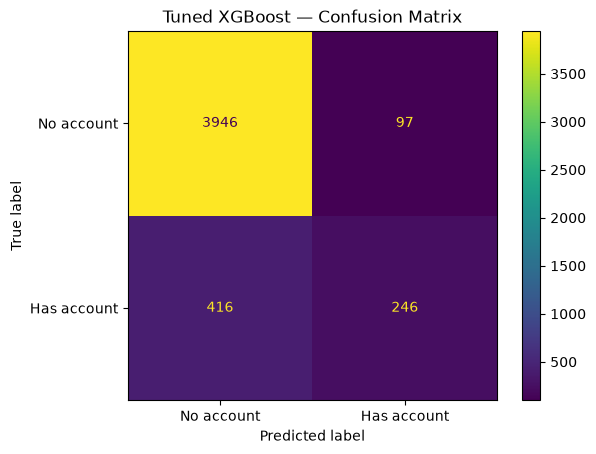

In [112]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_val,
    tuned_xgb_val_pred,
    display_labels=['No account', 'Has account']
)

plt.title('Tuned XGBoost — Confusion Matrix')
plt.show()

The tuned XGBoost achieves a lower error overall, but its errors are concentrated in false negatives: 
it misses 416 of 662 actual bank-account holders, resulting in a 37.2% recall

### Error Analysis

### Part 2

In [113]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_val,
        tuned_xgb_val_pred,
        target_names=['No account', 'Has account']
    )
)

              precision    recall  f1-score   support

  No account       0.90      0.98      0.94      4043
 Has account       0.72      0.37      0.49       662

    accuracy                           0.89      4705
   macro avg       0.81      0.67      0.71      4705
weighted avg       0.88      0.89      0.88      4705



For No account:

Precision 0.90 means: of everyone the model predicted as No account, 90% really had no account.
Recall 0.98 means: of everyone who really had No account, the model correctly identified 98%.
F1 0.94 means: precision and recall are both strong for this class.
Support 4043 means there were 4,043 actual No-account cases in the validation set.

For Has account:

Precision 0.72 means: when the model predicts Has account, it is correct about 72% of the time.
Recall 0.37 means: of all actual account holders, it only finds 37%.
F1 0.49 means: overall performance on the positive class is weak because recall is low, even though precision is reasonably good.
Support 662 means there were 662 actual account holders.

The model is very good at recognizing people without accounts, and fairly trustworthy when it predicts someone has an account, but it misses a large share of actual account holders.

That is the core imbalance in performance.

The accuracy = 0.89 is the overall share classified correctly. But because most people are in the No-account class, accuracy is dominated by how well the model handles that majority group.

The two averages at the bottom are useful too:

Macro average treats both classes equally, regardless of how many observations are in each class. So the model gets roughly equal weight for its performance on No-account and Has-account. That is why macro recall is only 0.67—the excellent 0.98 recall for No-account is being averaged with the weak 0.37 recall for Has-account.

Weighted average weights each class according to its support. Since No-account has 4,043 observations and Has-account only 662, the strong majority-class performance dominates. That is why weighted recall is 0.89, almost identical to accuracy.

So one very useful rule for imbalanced classification is:

Macro metrics reveal whether performance is balanced across classes; weighted metrics can look strong simply because the majority class is large.



The tuned XGBoost performs well overall, but performance is asymmetric: it identifies non-account holders very accurately while missing roughly 63% of actual account holders (from 0.37 recall)

In [ ]:
# Threshold differences

# Probability that each person in the validation set has a bank account
y_val_proba = tuned_xgb.predict_proba(X_val)[:, 1]

y_val_proba[:10]



array([0.7022309 , 0.12328904, 0.02103586, 0.00730211, 0.0785073 ,
       0.36850554, 0.0281192 , 0.1011999 , 0.03290031, 0.04298189],
      dtype=float32)

In [154]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:

    # Convert probabilities into 0/1 predictions
    y_pred_threshold = (y_val_proba >= threshold).astype(int)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_val,
        y_pred_threshold
    ).ravel()

    threshold_results.append({
        'Threshold': threshold,
        'Accuracy': accuracy_score(
            y_val,
            y_pred_threshold
        ),
        'Precision': precision_score(
            y_val,
            y_pred_threshold,
            zero_division=0
        ),
        'Recall': recall_score(
            y_val,
            y_pred_threshold
        ),
        'F1': f1_score(
            y_val,
            y_pred_threshold
        ),
        'False Positives': fp,
        'False Negatives': fn
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results

,Threshold,Accuracy,Precision,Recall,F1,False Positives,False Negatives
0,0.10,0.729649,0.326310,0.865559,0.473945,1183,89
1,0.15,0.797237,0.390390,0.785498,0.521565,812,142
2,0.20,0.839320,0.453280,0.688822,0.546763,550,206
3,0.25,0.861637,0.506732,0.625378,0.559838,403,248
4,0.30,0.877790,0.565022,0.570997,0.567994,291,284
5,0.35,0.883103,0.598940,0.512085,0.552117,227,323
6,0.40,0.885654,0.629707,0.454683,0.528070,177,361
7,0.45,0.887991,0.665848,0.409366,0.507016,136,391
8,0.50,0.890967,0.717201,0.371601,0.489552,97,416
9,0.55,0.889904,0.744898,0.330816,0.458159,75,443


In [155]:
threshold_display = threshold_results.copy()

for col in ['Accuracy', 'Precision', 'Recall', 'F1']:
    threshold_display[col] = (
        threshold_display[col] * 100
    ).round(1)

threshold_display['Threshold'] = (
    threshold_display['Threshold']
    .round(2)
)

threshold_display

,Threshold,Accuracy,Precision,Recall,F1,False Positives,False Negatives
0,0.10,73.0,32.6,86.6,47.4,1183,89
1,0.15,79.7,39.0,78.5,52.2,812,142
2,0.20,83.9,45.3,68.9,54.7,550,206
3,0.25,86.2,50.7,62.5,56.0,403,248
4,0.30,87.8,56.5,57.1,56.8,291,284
5,0.35,88.3,59.9,51.2,55.2,227,323
6,0.40,88.6,63.0,45.5,52.8,177,361
7,0.45,88.8,66.6,40.9,50.7,136,391
8,0.50,89.1,71.7,37.2,49.0,97,416
9,0.55,89.0,74.5,33.1,45.8,75,443


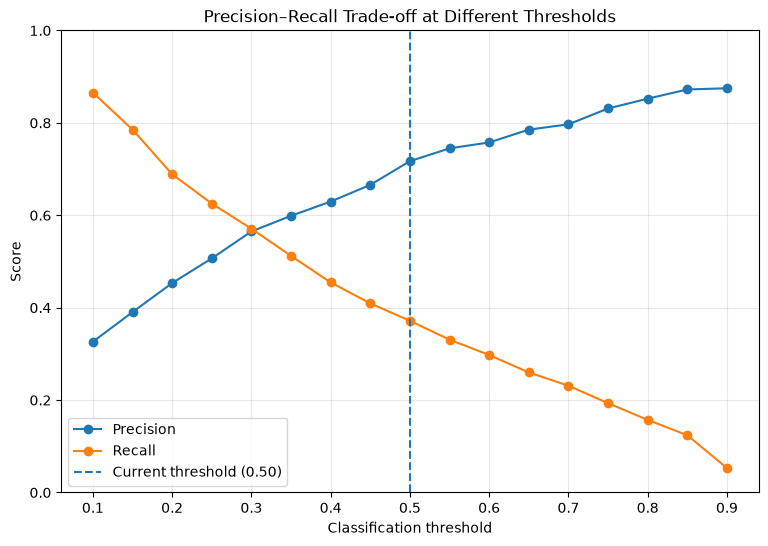

In [156]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.plot(
    threshold_results['Threshold'],
    threshold_results['Precision'],
    marker='o',
    label='Precision'
)

plt.plot(
    threshold_results['Threshold'],
    threshold_results['Recall'],
    marker='o',
    label='Recall'
)

plt.axvline(
    0.50,
    linestyle='--',
    label='Current threshold (0.50)'
)

plt.xlabel('Classification threshold')
plt.ylabel('Score')
plt.title('Precision–Recall Trade-off at Different Thresholds')

plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [157]:
selected_thresholds = threshold_results[
    threshold_results['Threshold'].round(2).isin(
        [0.20, 0.30, 0.40, 0.50, 0.60]
    )
].copy()

for col in ['Accuracy', 'Precision', 'Recall', 'F1']:
    selected_thresholds[col] = (
        selected_thresholds[col] * 100
    ).round(1)

selected_thresholds

,Threshold,Accuracy,Precision,Recall,F1,False Positives,False Negatives
2,0.2,83.9,45.3,68.9,54.7,550,206
4,0.3,87.8,56.5,57.1,56.8,291,284
6,0.4,88.6,63.0,45.5,52.8,177,361
8,0.5,89.1,71.7,37.2,49.0,97,416
10,0.6,88.8,75.8,29.8,42.7,63,465


### Interpretation

In [114]:
# Get the fitted preprocessing step
fitted_preprocessor = tuned_xgb.named_steps['prep']

# Get the transformed feature names
feature_names = fitted_preprocessor.get_feature_names_out()

print(feature_names)

['num__household_size' 'num__age_of_respondent' 'cat__country_Kenya'
 'cat__country_Rwanda' 'cat__country_Tanzania' 'cat__country_Uganda'
 'cat__year_2016' 'cat__year_2017' 'cat__year_2018'
 'cat__location_type_Rural' 'cat__location_type_Urban'
 'cat__cellphone_access_No' 'cat__cellphone_access_Yes'
 'cat__gender_of_respondent_Female' 'cat__gender_of_respondent_Male'
 'cat__relationship_with_head_Child'
 'cat__relationship_with_head_Head of Household'
 'cat__relationship_with_head_Other non-relatives'
 'cat__relationship_with_head_Other relative'
 'cat__relationship_with_head_Parent' 'cat__relationship_with_head_Spouse'
 'cat__marital_status_Divorced/Seperated' 'cat__marital_status_Dont know'
 'cat__marital_status_Married/Living together'
 'cat__marital_status_Single/Never Married' 'cat__marital_status_Widowed'
 'cat__education_level_No formal education'
 'cat__education_level_Other/Dont know/RTA'
 'cat__education_level_Primary education'
 'cat__education_level_Secondary education'
 'c

In [120]:
xgb_model = tuned_xgb.named_steps['model']

importances = xgb_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

feature_importance_df.head(15)

,Feature,Importance
11,cat__cellphone_access_No,0.163693
34,cat__job_type_Formally employed Government,0.155040
35,cat__job_type_Formally employed Private,0.090058
31,cat__education_level_Vocational/Specialised tr...,0.073268
26,cat__education_level_No formal education,0.057582
30,cat__education_level_Tertiary education,0.056886
29,cat__education_level_Secondary education,0.052267
28,cat__education_level_Primary education,0.048113
2,cat__country_Kenya,0.030617
4,cat__country_Tanzania,0.023529


At this stage, the features and their importance do not tell us the impact that this feature had on persons having an account (or not)

Currently, this just tells us which features were more important in the predictive modelling and this does not tells us the direction of the impact



In [121]:
def get_original_feature(feature_name):
    
    # Remove transformer prefixes
    feature_name = feature_name.replace('cat__', '').replace('num__', '')
    
    # Numeric features already have their original names
    if feature_name in ['age_of_respondent', 'household_size']:
        return feature_name
    
    # Find which categorical variable the one-hot feature came from
    for col in cat_cols:
        if feature_name.startswith(col + '_'):
            return col
    
    return feature_name

feature_importance_df['Original_Feature'] = (
    feature_importance_df['Feature']
    .apply(get_original_feature)
)

feature_importance_df.head(15)

,Feature,Importance,Original_Feature
11,cat__cellphone_access_No,0.163693,cellphone_access
34,cat__job_type_Formally employed Government,0.155040,job_type
35,cat__job_type_Formally employed Private,0.090058,job_type
31,cat__education_level_Vocational/Specialised tr...,0.073268,education_level
26,cat__education_level_No formal education,0.057582,education_level
30,cat__education_level_Tertiary education,0.056886,education_level
29,cat__education_level_Secondary education,0.052267,education_level
28,cat__education_level_Primary education,0.048113,education_level
2,cat__country_Kenya,0.030617,country
4,cat__country_Tanzania,0.023529,country


In [122]:
grouped_importance = (
    feature_importance_df
    .groupby('Original_Feature', as_index=False)['Importance']
    .sum()
    .sort_values('Importance', ascending=False)
)

grouped_importance

,Original_Feature,Importance
6,job_type,0.332166
3,education_level,0.292340
1,cellphone_access,0.163693
2,country,0.082171
9,relationship_with_head,0.049854
8,marital_status,0.024362
7,location_type,0.017438
4,gender_of_respondent,0.014199
0,age_of_respondent,0.011591
10,year,0.007470


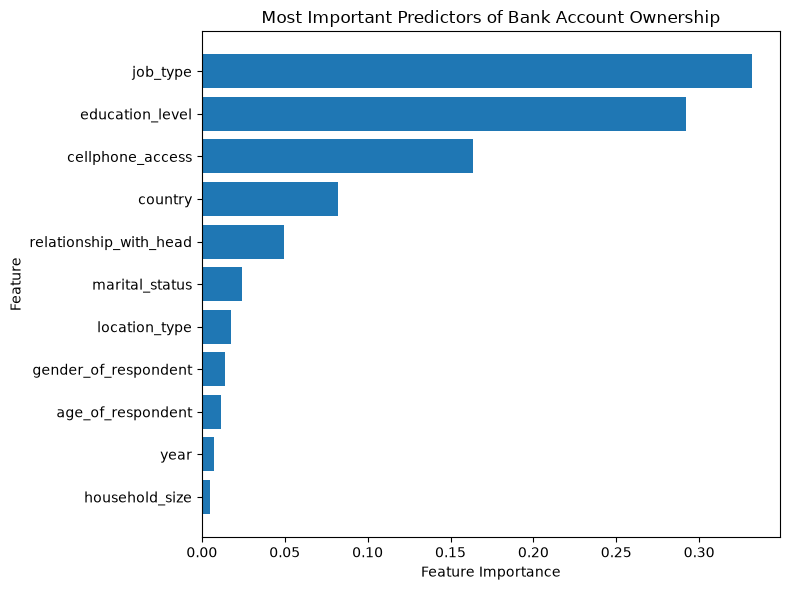

In [ ]:
# grouped importance chart

plt.figure(figsize=(8, 6))

plt.barh(
    grouped_importance['Original_Feature'],
    grouped_importance['Importance']
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Most Important Predictors of Bank Account Ownership')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [124]:
def get_original_feature(feature_name):
    feature_name = feature_name.replace('cat__', '').replace('num__', '')

    if feature_name in ['age_of_respondent', 'household_size']:
        return feature_name

    for col in cat_cols:
        if feature_name.startswith(col + '_'):
            return col

    return feature_name


feature_importance_df['Original_Feature'] = (
    feature_importance_df['Feature']
    .apply(get_original_feature)
)

grouped_importance = (
    feature_importance_df
    .groupby('Original_Feature', as_index=False)['Importance']
    .sum()
    .sort_values('Importance', ascending=False)
)

grouped_importance

,Original_Feature,Importance
6,job_type,0.332166
3,education_level,0.292340
1,cellphone_access,0.163693
2,country,0.082171
9,relationship_with_head,0.049854
8,marital_status,0.024362
7,location_type,0.017438
4,gender_of_respondent,0.014199
0,age_of_respondent,0.011591
10,year,0.007470


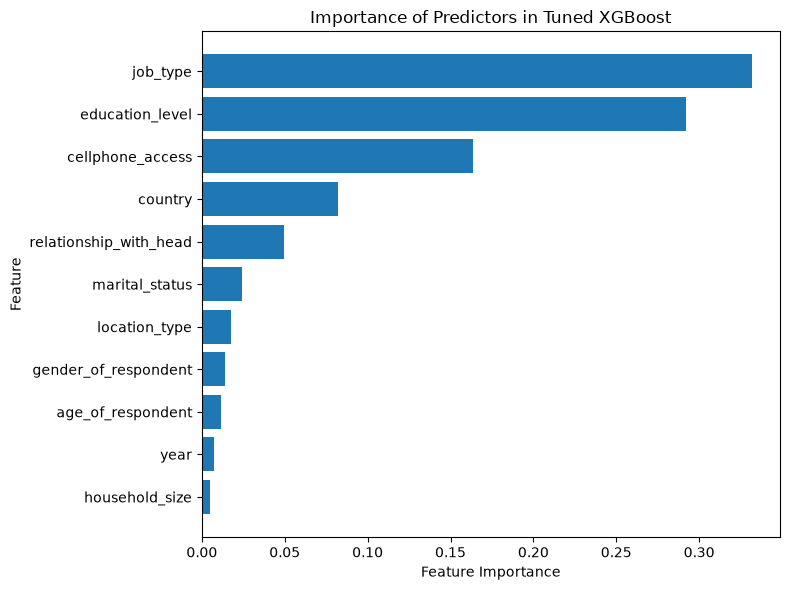

,Original_Feature,Importance
6,job_type,0.332166
3,education_level,0.292340
1,cellphone_access,0.163693
2,country,0.082171
9,relationship_with_head,0.049854
8,marital_status,0.024362
7,location_type,0.017438
4,gender_of_respondent,0.014199
0,age_of_respondent,0.011591
10,year,0.007470


In [ ]:
# finishing group importance

plt.figure(figsize=(8, 6))

plt.barh(
    grouped_importance['Original_Feature'],
    grouped_importance['Importance']
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Importance of Predictors in Tuned XGBoost')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

grouped_importance

In [127]:
# Next Permutation importance

from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    tuned_xgb,
    X_val,
    y_val,
    scoring='neg_mean_absolute_error',
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

permutation_df = pd.DataFrame({
    'Feature': X_val.columns,
    'Importance': perm_result.importances_mean,
    'Std': perm_result.importances_std
}).sort_values(
    'Importance',
    ascending=False
)

permutation_df




,Feature,Importance,Std
9,education_level,0.036557,0.002655
10,job_type,0.017035,0.001722
0,country,0.011764,0.001662
3,cellphone_access,0.007906,0.001605
5,age_of_respondent,0.006164,0.001324
2,location_type,0.003252,0.001302
7,relationship_with_head,0.001382,0.001055
8,marital_status,0.000808,0.000654
4,household_size,0.000287,0.000513
6,gender_of_respondent,-0.000213,0.000879


In [130]:
scoring='neg_mean_absolute_error'

permutation_df


,Feature,Importance,Std
9,education_level,0.036557,0.002655
10,job_type,0.017035,0.001722
0,country,0.011764,0.001662
3,cellphone_access,0.007906,0.001605
5,age_of_respondent,0.006164,0.001324
2,location_type,0.003252,0.001302
7,relationship_with_head,0.001382,0.001055
8,marital_status,0.000808,0.000654
4,household_size,0.000287,0.000513
6,gender_of_respondent,-0.000213,0.000879


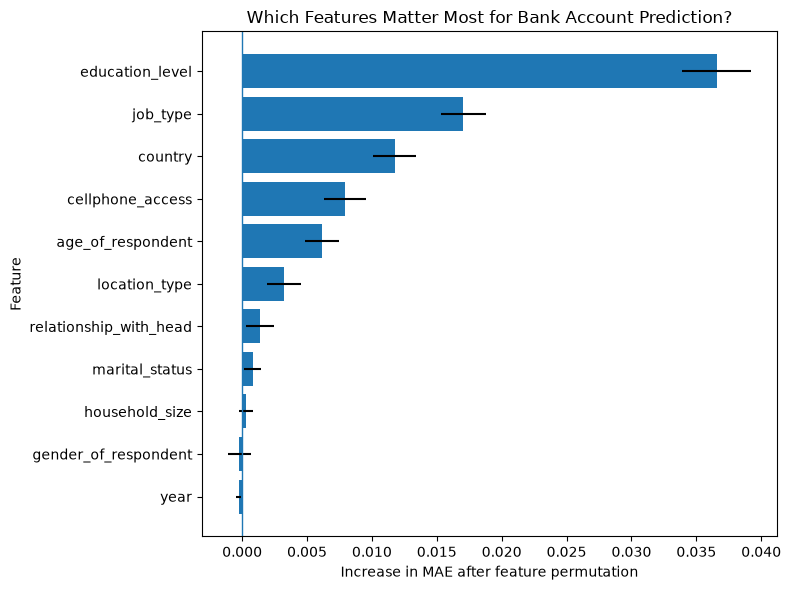

In [131]:
plt.figure(figsize=(8, 6))

plot_df = permutation_df.sort_values(
    'Importance',
    ascending=True
)

plt.barh(
    plot_df['Feature'],
    plot_df['Importance'],
    xerr=plot_df['Std']
)

plt.xlabel('Increase in MAE after feature permutation')
plt.ylabel('Feature')
plt.title('Which Features Matter Most for Bank Account Prediction?')

plt.axvline(0, linewidth=1)

plt.tight_layout()
plt.show()

Education level and employment type are the strongest predictors of bank-account ownership in the model, followed by country, cellphone access and age

### Error Analysis By Group

## Useful

This helps us to understand how the model performs on specific groups, such as country 

In [132]:
error_analysis = X_val.copy()

error_analysis['actual'] = y_val.values
error_analysis['predicted'] = tuned_xgb_val_pred

country_results = []

for country in error_analysis['country'].unique():

    group = error_analysis[
        error_analysis['country'] == country
    ]

    positive_cases = group['actual'].sum()

    country_results.append({
        'Country': country,
        'N': len(group),
        'Account holders': positive_cases,
        'Accuracy': accuracy_score(
            group['actual'],
            group['predicted']
        ),
        'Recall': recall_score(
            group['actual'],
            group['predicted']
        )
    })

country_results = pd.DataFrame(country_results)

country_results.sort_values(
    'Recall',
    ascending=False
)

,Country,N,Account holders,Accuracy,Recall
3,Uganda,473,36,0.951374,0.444444
0,Kenya,1209,314,0.809760,0.439490
2,Tanzania,1277,117,0.935004,0.410256
1,Rwanda,1746,195,0.898625,0.225641


This was a useful exercise because it shows that the previous 37% recall was hiding a significant country difference. Rwanda at 26% !

Rwanda has a high accuracy at 90% (relating to the accuracy of the prediction). However, the model identifies that less than 1 in 4 (23%) actual Rwandan's are account holders. 

In [140]:
def evaluate_by_group(data, group_col):
    
    results = []

    for group_name in data[group_col].unique():

        group = data[data[group_col] == group_name]

        results.append({
            group_col: group_name,
            'N': len(group),
            'Account holders': group['actual'].sum(),
            'Accuracy': accuracy_score(
                group['actual'],
                group['predicted']
            ),
            'Recall': recall_score(
                group['actual'],
                group['predicted']
            )
        })

    return pd.DataFrame(results).sort_values(
        'Recall',
        ascending=False
    )

print(evaluate_by_group(error_analysis, 'location_type'))

print(evaluate_by_group(error_analysis, 'gender_of_respondent'))

print(evaluate_by_group(error_analysis, 'education_level'))


  location_type     N  Account holders  Accuracy    Recall
0         Urban  1809              345  0.864013  0.498551
1         Rural  2896              317  0.907804  0.233438
  gender_of_respondent     N  Account holders  Accuracy    Recall
0                 Male  1913              358  0.862520  0.424581
1               Female  2792              304  0.910458  0.309211
                   education_level     N  Account holders  Accuracy    Recall
3               Tertiary education   245              131  0.804082  0.809160
4  Vocational/Specialised training   159               87  0.685535  0.747126
5              Other/Dont know/RTA    14                3  0.928571  0.666667
0              Secondary education   865              202  0.795376  0.306931
1                Primary education  2525              206  0.919208  0.053398
2              No formal education   897               33  0.963211  0.000000


The model is very effective at identifying account holders with tertiary or vocational education, but almost completely fails to identify account holders with little or no formal education

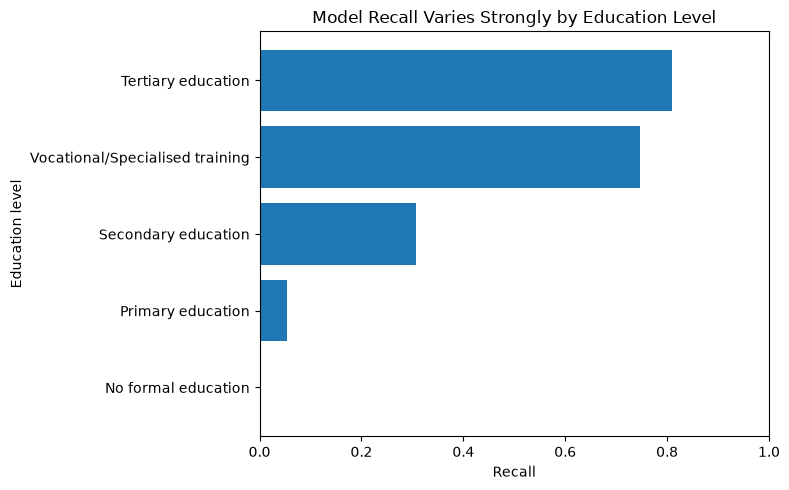

In [141]:
education_results = evaluate_by_group(
    error_analysis,
    'education_level'
)

education_results = education_results[
    education_results['Account holders'] >= 20
].sort_values('Recall')

plt.figure(figsize=(8, 5))

plt.barh(
    education_results['education_level'],
    education_results['Recall']
)

plt.xlabel('Recall')
plt.ylabel('Education level')
plt.title('Model Recall Varies Strongly by Education Level')

plt.xlim(0, 1)
plt.tight_layout()
plt.show()

FINAL MODEL

In [145]:
# All labelled training data

X_full = train.drop(
    columns=[target, 'uniqueid']
)

y_full = train[target].map({
    'Yes': 1,
    'No': 0
})

print(X_full.shape)
print(y_full.shape)
print(y_full.value_counts())

(23524, 11)
(23524,)
bank_account
0    20212
1     3312
Name: count, dtype: int64


In [146]:
# copy the tuned model

from sklearn.base import clone

final_model = clone(
    xgb_search.best_estimator_
)

In [147]:
# final fit

final_model.fit(
    X_full,
    y_full
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['country','year','location_type',...,'marital_status','education_level', 'job_type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``

TESTING PREDICTIONS

In [150]:
X_test_final = test.drop(
    columns=['uniqueid'],
    errors='ignore'
)

test_predictions = final_model.predict(
    X_test_final
)

print(test_predictions[:20])

[1 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 0 1]


In [152]:
#Verify the model

import numpy as np

print(
    np.unique(
        test_predictions,
        return_counts=True
    )
)

print(
    "Predicted account-holder rate:",
    test_predictions.mean()
)

(array([0, 1]), array([9362,  724]))
Predicted account-holder rate: 0.07178266904620266
